In [1]:
import numpy as np
import pandas as pd
import tensorflow as tf
import keras_tuner as kt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.utils.class_weight import compute_class_weight





from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, ConfusionMatrixDisplay, classification_report,
    mean_absolute_error, mean_squared_error, r2_score
)

pd.set_option('display.max_columns', None)

In [2]:
import pandas as pd

df = pd.read_csv('../data/raw/dataset_elpino.csv', sep=';')
cie_10 = pd.read_excel('../data/raw/CIE-10.xlsx')
cie_9  = pd.read_excel('../data/raw/CIE-9.xlsx')

df_chapter = df.copy()
df_chapter

,Diag 01 Principal (cod+des),Diag 02 Secundario (cod+des),Diag 03 Secundario (cod+des),Diag 04 Secundario (cod+des),Diag 05 Secundario (cod+des),Diag 06 Secundario (cod+des),Diag 07 Secundario (cod+des),Diag 08 Secundario (cod+des),Diag 09 Secundario (cod+des),Diag 10 Secundario (cod+des),Diag 11 Secundario (cod+des),Diag 12 Secundario (cod+des),Diag 13 Secundario (cod+des),Diag 14 Secundario (cod+des),Diag 15 Secundario (cod+des),Diag 16 Secundario (cod+des),Diag 17 Secundario (cod+des),Diag 18 Secundario (cod+des),Diag 19 Secundario (cod+des),Diag 20 Secundario (cod+des),Diag 21 Secundario (cod+des),Diag 22 Secundario (cod+des),Diag 23 Secundario (cod+des),Diag 24 Secundario (cod+des),Diag 25 Secundario (cod+des),Diag 26 Secundario (cod+des),Diag 27 Secundario (cod+des),Diag 28 Secundario (cod+des),Diag 29 Secundario (cod+des),Diag 30 Secundario (cod+des),Diag 31 Secundario (cod+des),Diag 32 Secundario (cod+des),Diag 33 Secundario (cod+des),Diag 34 Secundario (cod+des),Diag 35 Secundario (cod+des),Proced 01 Principal (cod+des),Proced 02 Secundario (cod+des),Proced 03 Secundario (cod+des),Proced 04 Secundario (cod+des),Proced 05 Secundario (cod+des),Proced 06 Secundario (cod+des),Proced 07 Secundario (cod+des),Proced 08 Secundario (cod+des),Proced 09 Secundario (cod+des),Proced 10 Secundario (cod+des),Proced 11 Secundario (cod+des),Proced 12 Secundario (cod+des),Proced 13 Secundario (cod+des),Proced 14 Secundario (cod+des),Proced 15 Secundario (cod+des),Proced 16 Secundario (cod+des),Proced 17 Secundario (cod+des),Proced 18 Secundario (cod+des),Proced 19 Secundario (cod+des),Proced 20 Secundario (cod+des),Proced 21 Secundario (cod+des),Proced 22 Secundario (cod+des),Proced 23 Secundario (cod+des),Proced 24 Secundario (cod+des),Proced 25 Secundario (cod+des),Proced 26 Secundario (cod+des),Proced 27 Secundario (cod+des),Proced 28 Secundario (cod+des),Proced 29 Secundario (cod+des),Proced 30 Secundario (cod+des),Edad en años,Sexo (Desc),GRD
0,A41.8 - Otras septicemias especificadas,B37.6 - Endocarditis debida a candida (I39.8*),"I39.8 - Endocarditis, válvula no especificada,...",N10 - Nefritis tubulointersticial aguda,B96.1 - Klebsiella pneumoniae [K. pneumoniae] ...,L89.9 - Úlcera de decúbito y area de presión n...,L08.9 - Infección local de la piel y del tejid...,B96.2 - Escherichia coli [E. coli] como causa ...,A41.5 - Sepsis por otros organnismos Gram nega...,J86.9 - Piotórax sin fístula,"U07.1 - COVID-19, virus identificado",Y95 - Afección nosocomial,"N18.5 - Enfermedad renal crónica, estadio 5",E87.1 - Hiposmolaridad e hiponatremia,D64.9 - Anemia de tipo no especificado,"G82.2 - Paraplejía, no especificada","N31.9 - Disfunción neuromuscular de la vejiga,...",I10 - Hipertensión esencial (primaria),K70.4 - Insuficiencia hepática alcohólica,F19.2 - Trastornos mentales y del comportamien...,F10.2 - Trastornos mentales y del comportamien...,"E46 - Desnutrición proteicocalórica, no especi...","G40.9 - Epilepsia, tipo no especificado","L21.9 - Dermatitis seborreica, no especificada",Z93.5 - Cistostomía,Z93.3 - Colostomía,Z99.2 - Dependencia de diálisis renal,Z91.6 - Historia personal de otro trauma físico,-,-,-,-,-,-,-,"86.28 - DESBRIDAMIENTO HERIDA,INFECCION O QUEM...",34.91 - TORACOCENTESIS,88.38 - TOMOGRAFIA AXIAL COMPUTERIZADA OTRA,87.41 - TOMOGRAFIA AXIAL COMPUTERIZADA TORAX,88.75 - ECOGRAFIA APARATO URINARIO,88.01 - TOMOGRAFIA AXIAL COMPUTERIZADA ABDOMEN,88.43 - ARTERIOGRAFIA ARTERIA PULMONAR,88.41 - ARTERIOGRAFIA ARTERIA CEREBRAL,87.44 - RADIOGRAFIA TORAX RUTINARIA,99.29 - INYECCION SUSTANCIA TERAPEUTICA O PROF...,99.19 - INYECCION ANTICOAGULANTE,99.18 - INYECCION ELECTROLITO,99.21 - INYECCION ANTIBIOTICO,99.26 - INYECCION TRANQUILIZANTE,99.23 - INYECCION ESTEROIDE,93.94 - AEROSOLTERAPIA,89.52 - ELECTROCARDIOGRAFIA,90.59 - EXAMEN MICROSCOPICO SANGRE.OTRO,89.65 - GASOMETRIA ARTERIA,39.95 - HEMODIALISIS,39.95 - HEMODIALISIS,99.04 - TRANSFUSION CONCENTRADO HEMATIES,90.39 - EXAMEN MICROSCOPICO ORL.OTRO,99.84 - AISLAMIENTO,88.7

## Agrupación por capítulos
CIE-10 y CIE-9 se pueden agrupar por categorias (ya hecho) y aparte por capitulos.
Este ultimo reduce la cardinalidad del feature considerablemente, solucionando el problema a la hora de escoger el encoder

In [3]:
# def cie_10_analisis(df):
cie_10['Capítulo'].unique()
cie_9['Capítulo'].unique()
# cie_10['Capítulo'].nunique()

<StringArray>
['00. (00 00) PROCEDIMIENTOS E INTERVENCIONES NO CLASIFICADOS BAJO OTROS CONCEPTOS',
                                '01. (01 05) OPERACIONES SOBRE EL SISTEMA NERVIOSO',
                               '02. (06 07) OPERACIONES SOBRE EL SISTEMA ENDOCRINO',
                                             '03. (08 16) OPERACIONES SOBRE EL OJO',
           '03A. (17 17) OTROS PROCEDIMIENTOS DIAGNOSTICOS Y TERAPEUTICOS DIVERSOS',
                                            '04. (18 20) OPERACIONES SOBRE EL OIDO',
                           '05. (21 29) OPERACIONES SOBRE LA NARIZ, BOCA Y FARINGE',
                            '06. (30 34) OPERACIONES SOBRE EL APARATO RESPIRATORIO',
                          '07. (35 39) OPERACIONES SOBRE EL APARATO CARDIOVASCULAR',
                    '08. (40 41) OPERACIONES SOBRE EL SISTEMA HEMATICO Y LINFATICO',
                               '09. (42 54) OPERACIONES SOBRE EL APARATO DIGESTIVO',
                                '10. (55 59) OPERAC

In [4]:
cie_9['Código']
df['Proced 01 Principal (cod+des)'].head()

0    86.28 - DESBRIDAMIENTO HERIDA,INFECCION O QUEM...
1                        31.1 - TRAQUEOSTOMIA TEMPORAL
2    86.22 - DESBRIDAMIENTO HERIDA,INFECCION O QUEM...
3                             54.19 - LAPAROTOMIA.OTRA
4                     54.11 - LAPAROTOMIA EXPLORATORIA
Name: Proced 01 Principal (cod+des), dtype: str

procedemos a crear dos DF para cie-9 y cie-10 respectivamente en donde se tenga su clave - valor de la categoria : capitulo al que pertenece

In [5]:
cie_10[['Código', 'Capítulo']]
map_cie10 = (
    cie_10[['Código', 'Capítulo']]
    .dropna()
    .assign(
        Categoria=lambda x: x['Código'].astype(str).str.strip().str.upper().str[:3],
        Capitulo=lambda x: x['Capítulo'].astype(str).str.strip()
    )[['Categoria', 'Capitulo']]
    .drop_duplicates('Categoria')
)
cie_10_dict = dict(zip(map_cie10['Categoria'], map_cie10['Capitulo']))
print(cie_10_dict['X80'])
def CIE9_to_categorie(df):
        cols_proc = [c for c in df.columns if  'Proced' in c and '(cod+des)'in c]
        for col in cols_proc:
            df[col] = (
                df[col].fillna('').astype(str)
                .str.split(" - ").str[0].str[:2])


map_cie9 = (
    cie_9[['Código', 'Capítulo']]
    .dropna()
    .assign(
        Categoria=lambda x: (
            x['Código']
            .astype(str)
            .str.strip()
            .str.split('.').str[0]  
            .str[:2]
        ),
        Capitulo=lambda x: x['Capítulo'].astype(str).str.strip()
    )[['Categoria', 'Capitulo']]
    .drop_duplicates('Categoria')
)
cie_9_dict = dict(zip(map_cie9['Categoria'], map_cie9['Capitulo']))
cie_10_dict.update({
    '-': 'SIN_CODIGO'
})
cie_9_dict.update({
    '-': 'SIN_CODIGO'
})

Cap.20  CAUSAS EXTERNAS DE MORBILIDAD (V00-Y99)


In [6]:
df_categories = pd.read_csv('../data/processed/elpino_categories.csv')
df_categories[df_categories['Proced 01 Principal (cod+des)'] == 0]



,Diag 01 Principal (cod+des),Diag 02 Secundario (cod+des),Diag 03 Secundario (cod+des),Diag 04 Secundario (cod+des),Diag 05 Secundario (cod+des),Diag 06 Secundario (cod+des),Diag 07 Secundario (cod+des),Diag 08 Secundario (cod+des),Diag 09 Secundario (cod+des),Diag 10 Secundario (cod+des),Diag 11 Secundario (cod+des),Diag 12 Secundario (cod+des),Diag 13 Secundario (cod+des),Diag 14 Secundario (cod+des),Diag 15 Secundario (cod+des),Diag 16 Secundario (cod+des),Diag 17 Secundario (cod+des),Diag 18 Secundario (cod+des),Diag 19 Secundario (cod+des),Diag 20 Secundario (cod+des),Diag 21 Secundario (cod+des),Diag 22 Secundario (cod+des),Diag 23 Secundario (cod+des),Diag 24 Secundario (cod+des),Diag 25 Secundario (cod+des),Diag 26 Secundario (cod+des),Diag 27 Secundario (cod+des),Diag 28 Secundario (cod+des),Diag 29 Secundario (cod+des),Diag 30 Secundario (cod+des),Diag 31 Secundario (cod+des),Diag 32 Secundario (cod+des),Diag 33 Secundario (cod+des),Diag 34 Secundario (cod+des),Diag 35 Secundario (cod+des),Proced 01 Principal (cod+des),Proced 02 Secundario (cod+des),Proced 03 Secundario (cod+des),Proced 04 Secundario (cod+des),Proced 05 Secundario (cod+des),Proced 06 Secundario (cod+des),Proced 07 Secundario (cod+des),Proced 08 Secundario (cod+des),Proced 09 Secundario (cod+des),Proced 10 Secundario (cod+des),Proced 11 Secundario (cod+des),Proced 12 Secundario (cod+des),Proced 13 Secundario (cod+des),Proced 14 Secundario (cod+des),Proced 15 Secundario (cod+des),Proced 16 Secundario (cod+des),Proced 17 Secundario (cod+des),Proced 18 Secundario (cod+des),Proced 19 Secundario (cod+des),Proced 20 Secundario (cod+des),Proced 21 Secundario (cod+des),Proced 22 Secundario (cod+des),Proced 23 Secundario (cod+des),Proced 24 Secundario (cod+des),Proced 25 Secundario (cod+des),Proced 26 Secundario (cod+des),Proced 27 Secundario (cod+des),Proced 28 Secundario (cod+des),Proced 29 Secundario (cod+des),Proced 30 Secundario (cod+des),Edad en años,Sexo (Desc),GRD
2012,I21,N18,T82,E10,E83,E87,R57,J96,E87,I10,Z90,Z99,Z99,Z92,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,0,36,00,00,88,87,88,88,88,87,39,89,89,38,00,93,89,89,99,99,99,99,99,90,90,90,93,93,93,93,44,1,54103
2597,I63,Y84,I25,I20,I10,E03,C61,Z86,Z92,Z88,Z92,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,0,88,88,87,88,89,89,89,99,99,99,90,90,93,93,93,93,93,93,93,93,93,-,-,-,-,-,-,-,-,80,1,14142
2974,U07,J12,R06,J96,J90,Z01,Z29,I50,I20,I70,I83,J44,I10,N17,N18,N40,E87,E87,E11,N08,H26,H91,Z92,Z86,Z55,-,-,-,-,-,-,-,-,-,-,0,36,00,00,88,87,88,88,88,88,87,89,38,39,93,90,90,91,91,99,99,99,93,89,89,99,99,99,57,97,78,1,44153
3584,N39,B96,J44,N18,F32,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,0,90,90,89,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,59,1,114122
4076,I21,F17,L89,Z88,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,0,36,00,00,88,87,89,89,90,90,99,93,99,89,89,93,93,93,93,93,93,93,93,93,89,-,-,-,-,-,55,1,54101
5471,C34,A41,J96,N17,I42,I13,Z72,Z92,Z51,Z02,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,0,99,99,93,93,93,93,89,90,90,89,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,70,1,44143
5479,I21,I50,F17,E83,E83,I10,E78,Z20,Z90,Z92,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,0,36,00,00,88,88,89,89,99,99,90,90,89,89,93,93,93,93,93,93,93,93,89,-,-,-,-,-,-,-,53,1,54102
5540,I21,I50,N18,E87,E87,E87,E11,I10,Z90,Z99,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,0,36,00,00,88,87,88,39,89,99,99,93,93,99,90,90,89,93,93,93,93,93,93,93,93,-,-,-,-,-,72,0,54102
7162,I21,I46,A41,R57,J15,Y95,Y84,J69,Y84,J20,N17,I50,N20,E87,L89,F05,I10,F17,E74,B96,U83,-,-,-,-,-,-,-,-,-,-,-,-,-,-,0,36,00,00,88,99,99,99,96,93,87,87,88,88,87,96,00,38,89,89,99,99,99,99,99,93,93,90,90,90,64,1,41023
8966,U07,J12,R05,R06,Z01,Z29,I21,I46,R57,R57,R65,I26,I63,I25,J69,Y84,I48,J96,N17,I50,S30,E11,L89,I10,N39,B95,D64,E87,E86,F05,B95,B96,-,-,-,0,36,00,00,88,31,96,93,88,88,87,88,88,87,88,88,89,87,89,00,89,99,96,38,89,91,90,90,90,90,66,1,41013


In [7]:
df_chapter = df_categories.copy()
df_chapter['Proced 14 Secundario (cod+des)']

0        99
1        99
2        90
3        88
4        99
         ..
14556     -
14557     -
14558     -
14559     -
14560    00
Name: Proced 14 Secundario (cod+des), Length: 14561, dtype: str

In [8]:
def CIE10_to_chapter(df):
        cols_diag = [c for c in df.columns if  'Diag' in c and '(cod+des)'in c]
        for col in cols_diag:
            df[col] = (
                df[col].map(cie_10_dict)
            )
def CIE9_to_chapter( df):
    cols_proc = [c for c in df.columns if  'Proced' in c and '(cod+des)'in c]
    for col in cols_proc:
        df[col] = (
            df[col].astype(str).map(cie_9_dict)
        )
CIE9_to_chapter(df_chapter)
CIE10_to_chapter(df_chapter)
df_chapter

,Diag 01 Principal (cod+des),Diag 02 Secundario (cod+des),Diag 03 Secundario (cod+des),Diag 04 Secundario (cod+des),Diag 05 Secundario (cod+des),Diag 06 Secundario (cod+des),Diag 07 Secundario (cod+des),Diag 08 Secundario (cod+des),Diag 09 Secundario (cod+des),Diag 10 Secundario (cod+des),Diag 11 Secundario (cod+des),Diag 12 Secundario (cod+des),Diag 13 Secundario (cod+des),Diag 14 Secundario (cod+des),Diag 15 Secundario (cod+des),Diag 16 Secundario (cod+des),Diag 17 Secundario (cod+des),Diag 18 Secundario (cod+des),Diag 19 Secundario (cod+des),Diag 20 Secundario (cod+des),Diag 21 Secundario (cod+des),Diag 22 Secundario (cod+des),Diag 23 Secundario (cod+des),Diag 24 Secundario (cod+des),Diag 25 Secundario (cod+des),Diag 26 Secundario (cod+des),Diag 27 Secundario (cod+des),Diag 28 Secundario (cod+des),Diag 29 Secundario (cod+des),Diag 30 Secundario (cod+des),Diag 31 Secundario (cod+des),Diag 32 Secundario (cod+des),Diag 33 Secundario (cod+des),Diag 34 Secundario (cod+des),Diag 35 Secundario (cod+des),Proced 01 Principal (cod+des),Proced 02 Secundario (cod+des),Proced 03 Secundario (cod+des),Proced 04 Secundario (cod+des),Proced 05 Secundario (cod+des),Proced 06 Secundario (cod+des),Proced 07 Secundario (cod+des),Proced 08 Secundario (cod+des),Proced 09 Secundario (cod+des),Proced 10 Secundario (cod+des),Proced 11 Secundario (cod+des),Proced 12 Secundario (cod+des),Proced 13 Secundario (cod+des),Proced 14 Secundario (cod+des),Proced 15 Secundario (cod+des),Proced 16 Secundario (cod+des),Proced 17 Secundario (cod+des),Proced 18 Secundario (cod+des),Proced 19 Secundario (cod+des),Proced 20 Secundario (cod+des),Proced 21 Secundario (cod+des),Proced 22 Secundario (cod+des),Proced 23 Secundario (cod+des),Proced 24 Secundario (cod+des),Proced 25 Secundario (cod+des),Proced 26 Secundario (cod+des),Proced 27 Secundario (cod+des),Proced 28 Secundario (cod+des),Proced 29 Secundario (cod+des),Proced 30 Secundario (cod+des),Edad en años,Sexo (Desc),GRD
0,Cap.01 CIERTAS ENFERMEDADES INFECCIOSAS Y PAR...,Cap.01 CIERTAS ENFERMEDADES INFECCIOSAS Y PAR...,Cap.09 ENFERMEDADES DEL APARATO CIRCULATORIO ...,Cap.14 ENFERMEDADES DEL APARATO GENITOURINARI...,Cap.01 CIERTAS ENFERMEDADES INFECCIOSAS Y PAR...,Cap.12 ENFERMEDADES DE LA PIEL Y DEL TEJIDO S...,Cap.12 ENFERMEDADES DE LA PIEL Y DEL TEJIDO S...,Cap.01 CIERTAS ENFERMEDADES INFECCIOSAS Y PAR...,Cap.01 CIERTAS ENFERMEDADES INFECCIOSAS Y PAR...,Cap.10 ENFERMEDADES DEL APARATO RESPIRATORIO ...,Cap.22 CÓDIGOS PARA SITUACIONES ESPECIALES (U...,Cap.20 CAUSAS EXTERNAS DE MORBILIDAD (V00-Y99),Cap.14 ENFERMEDADES DEL APARATO GENITOURINARI...,"Cap.04 ENFERMEDADES ENDOCRINAS, NUTRICIONALES...",Cap.03 ENFERMEDADES DE LA SANGRE Y ÓRGANOS HE...,Cap.06 ENFERMEDADES DEL SISTEMA NERVIOSO (G00...,Cap.14 ENFERMEDADES DEL APARATO GENITOURINARI...,Cap.09 ENFERMEDADES DEL APARATO CIRCULATORIO ...,Cap.11 ENFERMEDADES DEL APARATO DIGESTIVO (K0...,Cap.05 TRASTORNOS MENTALES Y DE COMPORTAMIENT...,Cap.05 TRASTORNOS MENTALES Y DE COMPORTAMIENT...,"Cap.04 ENFERMEDADES ENDOCRINAS, NUTRICIONALES...",Cap.06 ENFERMEDADES DEL SISTEMA NERVIOSO (G00...,Cap.12 ENFERMEDADES DE LA PIEL Y DEL TEJIDO S...,Cap.21 FACTORES QUE INFLUYEN EN EL ESTADO DE ...,Cap.21 FACTORES QUE INFLUYEN EN EL ESTADO DE ...,Cap.21 FACTORES QUE INFLUYEN EN EL ESTADO DE ...,Cap.21 FACTORES QUE INFLUYEN EN EL ESTADO DE ...,SIN_CODIGO,SIN_CODIGO,SIN_CODIGO,SIN_CODIGO,SIN_CODIGO,SIN_CODIGO,SIN_CODIGO,15. (85 86) OPERACIONES SOBRE EL APARATO TEGUM...,06. (30 34) OPERACIONES SOBRE EL APARATO RESPI...,16. (87 99) PROCEDIMIENTOS DIAGNOSTICOS Y TERA...,16. (87 99) PROCEDIMIENTOS DIAGNOSTICOS Y TERA...,16. (87 99) PROCEDIMIENTOS DIAGNOSTICOS Y TERA...,16. (87 99) PROCEDIMIENTOS DIAGNOSTICOS Y TERA...,16. (87 99) PROCEDIMIENTOS DIAGNOSTICOS Y TERA...,16. (87 99) PROCEDIMIENTOS DIAGNOSTICOS Y TERA...,16. (87 99) PROCEDIMIENTOS DIAGNOSTICOS Y TERA...,16. (87 99) PROCEDIMIENTOS DIAGNOSTICOS Y TERA...,16. (87 99) PROCEDIMIENTOS DIAGNOSTICOS Y TERA...,16. (87 99) PROCEDIMIENT

Tipos de datos: 


,tipo
Diag 01 Principal (cod+des),str
Diag 02 Secundario (cod+des),str
Diag 03 Secundario (cod+des),str
Diag 04 Secundario (cod+des),str
Diag 05 Secundario (cod+des),str
...,...
Proced 29 Secundario (cod+des),str
Proced 30 Secundario (cod+des),str
Edad en años,int64
Sexo (Desc),int64



 Valores faltantes por columna


,Valores faltantes
Diag 01 Principal (cod+des),0
Diag 02 Secundario (cod+des),32
Diag 03 Secundario (cod+des),27
Diag 04 Secundario (cod+des),34
Diag 05 Secundario (cod+des),27
...,...
Proced 29 Secundario (cod+des),5
Proced 30 Secundario (cod+des),9
Edad en años,0
Sexo (Desc),0



Variables con alta cardinalidad ( > 100 categorías):


,Unique_Values



 Estadística descriptiva


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Diag 01 Principal (cod+des),14561,21,"Cap.15 EMBARAZO, PARTO Y PUERPERIO (O00-O9A)",3896,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Diag 02 Secundario (cod+des),14529,23,"Cap.15 EMBARAZO, PARTO Y PUERPERIO (O00-O9A)",3184,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Diag 03 Secundario (cod+des),14534,23,SIN_CODIGO,2687,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Diag 04 Secundario (cod+des),14527,23,SIN_CODIGO,4127,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Diag 05 Secundario (cod+des),14534,23,SIN_CODIGO,5371,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...
Proced 29 Secundario (cod+des),14556,5,SIN_CODIGO,13379,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Proced 30 Secundario (cod+des),14552,6,SIN_CODIGO,13498,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Edad en años,14561.0,NaN,NaN,NaN,39.42655,24.681545,0.0,23.0,36.0,60.0,121.0
Sexo (Desc),14561.0,NaN,NaN,NaN,0.339537,0.473568,0.0,0.0,0.0,1.0,1.0



Distribución de la variable objetivo:


,conteo
GRD,
146101,813
146121,639
146131,538
158171,389
134161,325
...,...
164142,1
101202,1
134101,1


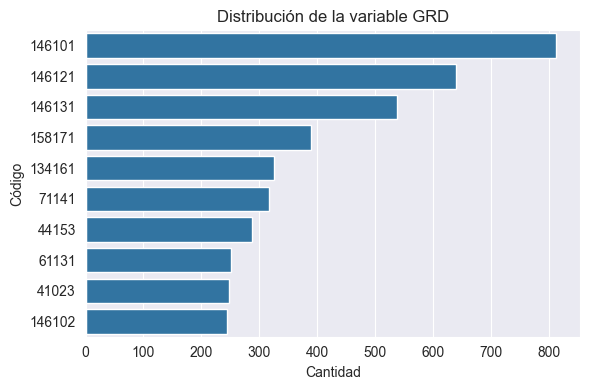


Columnas categóricas - Top 5 valores:

Diag 01 Principal (cod+des):
Diag 01 Principal (cod+des)
Cap.15  EMBARAZO, PARTO Y PUERPERIO (O00-O9A)                3896
Cap.11  ENFERMEDADES DEL APARATO DIGESTIVO (K00-K95)         2029
Cap.09  ENFERMEDADES DEL APARATO CIRCULATORIO (I00-I99)      1247
Cap.14  ENFERMEDADES DEL APARATO GENITOURINARIO (N00-N99)    1215
Cap.10  ENFERMEDADES DEL APARATO RESPIRATORIO (J00-J99)      1192
Name: count, dtype: int64

Diag 02 Secundario (cod+des):
Diag 02 Secundario (cod+des)
Cap.15  EMBARAZO, PARTO Y PUERPERIO (O00-O9A)                             3184
Cap.09  ENFERMEDADES DEL APARATO CIRCULATORIO (I00-I99)                   1692
Cap.10  ENFERMEDADES DEL APARATO RESPIRATORIO (J00-J99)                   1526
SIN_CODIGO                                                                1209
Cap.04  ENFERMEDADES ENDOCRINAS, NUTRICIONALES Y METABÓLICAS (E00-E89)     828
Name: count, dtype: int64

Diag 03 Secundario (cod+des):
Diag 03 Secundario (cod+des)
SIN_CO

In [9]:
import sys
sys.path.append("..")


from src.data.EDA import EDA
eda = EDA()
eda.summaryEda(df_chapter, 'GRD')

In [69]:
df_chapter['GRD'].nunique()

526

## Random Forest

In [26]:
from imblearn.combine import SMOTETomek
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

target = "GRD"
X = df_chapter.drop(columns=[target])
y = df_chapter[target]

counts = y.value_counts()
valid = counts[counts >= 2].index
mask = y.isin(valid)

X2 = X.loc[mask].copy()
y2 = y.loc[mask].copy()

X_train, X_test, y_train, y_test = train_test_split(
    X2, y2, test_size=0.2, random_state=42, stratify=y2
)

cat_cols = X2.select_dtypes(include=["object", "category"]).columns.tolist()
num_cols = X2.select_dtypes(exclude=["object", "category"]).columns.tolist()

prepro = ColumnTransformer([
    ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), cat_cols),
    ("num", "passthrough", num_cols),
])

modelo_rf_b = ImbPipeline([
    ("prep", prepro),
    ("smote_tomek", SMOTETomek(
        smote=SMOTE(k_neighbors=1, random_state=42),
        random_state=42
    )),
    ("rf", RandomForestClassifier(
        n_estimators=200,
        max_depth=8,
        min_samples_leaf=3,
        random_state=42
    ))
])

modelo_rf_b.fit(X_train, y_train)
pred_b = modelo_rf_b.predict(X_test)
print(classification_report(y_test, pred_b))

KeyboardInterrupt: 

## Encoding para la nueva cardinalidad


In [59]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()

Resultados del modelo
   accuracy: 0.4115
  precision: 0.1137
     recall: 0.1245
         f1: 0.1092
Reporte de clasificación
              precision    recall  f1-score   support

       14112       0.00      0.00      0.00         1
       14113       0.00      0.00      0.00         1
       14131       0.00      0.00      0.00         2
       14132       0.00      0.00      0.00         2
       14133       0.00      0.00      0.00         3
       14141       0.20      0.31      0.24        13
       14142       0.11      0.17      0.13        18
       14143       0.15      0.15      0.15        13
       14161       0.00      0.00      0.00         2
       14162       0.00      0.00      0.00         2
       14171       0.00      0.00      0.00         1
       14213       0.00      0.00      0.00         1
       14221       0.19      0.56      0.28         9
       14222       0.00      0.00      0.00         5
       14223       0.00      0.00      0.00         2
       1

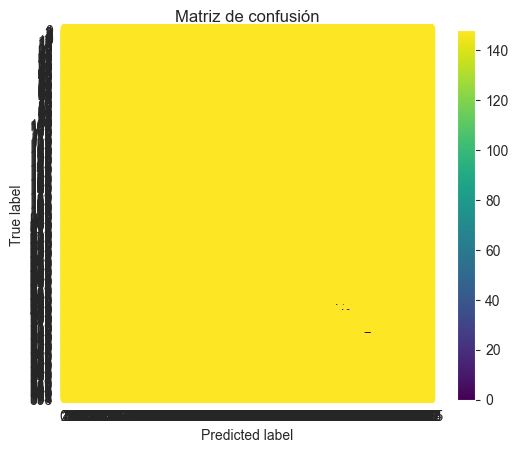

In [ ]:
import warnings
warnings.filterwarnings('ignore')

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier, MLPRegressor
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, ConfusionMatrixDisplay, classification_report,
    mean_absolute_error, mean_squared_error, r2_score
)
target = 'GRD'

X = df_chapter.drop(columns=[target])
y = df_chapter[target]
le
counts = y.value_counts()
valid = counts[counts >= 2].index
mask = y.isin(valid)
X2 = X.loc[mask].copy()
y2 = y.loc[mask].copy()



cat_cols = X.select_dtypes(include='object').columns.tolist()
num_cols = X.select_dtypes(exclude='object').columns.tolist()
cat_cols
num_cols
X_train, X_test, y_train, y_test = train_test_split(
    X2, y2, test_size=0.2, random_state=42, stratify=y2
)
X_train
def crear_pipeline_mlp_clasificador(hidden_layer_sizes=(24, 12), alpha=0.0005, max_iter=1200):
    prepro = ColumnTransformer([
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols),
        ("num", StandardScaler(), num_cols),
    ])
    
    return Pipeline([
        ("prep", prepro),
        ("mlp", MLPClassifier(
            hidden_layer_sizes=hidden_layer_sizes,
            activation="relu",
            solver="adam",
            alpha=alpha,
            random_state=204,
            early_stopping=True,
            max_iter=max_iter
        ))
    ])
modelo_B = crear_pipeline_mlp_clasificador(hidden_layer_sizes=(24, 12), alpha=0.0005)

def evaluar_clasificacion(modelo, X_train, X_test, y_train, y_test, promedio='binary'):
    modelo.fit(X_train, y_train)
    pred = modelo.predict(X_test)

    metricas = {
        'accuracy': accuracy_score(y_test, pred),
        'precision': precision_score(y_test, pred, average=promedio, zero_division=0),
        'recall': recall_score(y_test, pred, average=promedio, zero_division=0),
        'f1': f1_score(y_test, pred, average=promedio, zero_division=0),
    }

    print('Resultados del modelo')
    for k, v in metricas.items():
        print(f'  {k:>9}: {v:.4f}')

    print('Reporte de clasificación')
    print(classification_report(y_test, pred, zero_division=0))

    cm = confusion_matrix(y_test, pred)
    ConfusionMatrixDisplay(cm).plot()
    plt.title('Matriz de confusión')
    plt.show()

    return pred, metricas
pred_B, metricas_B = evaluar_clasificacion(modelo_B, X_train, X_test, y_train, y_test, promedio='macro')

In [71]:
def comparar_arquitecturas_clasificacion(X_train, X_test, y_train, y_test, arquitecturas, alpha=0.0005, promedio='binary'):
    filas = []
    for arq in arquitecturas:
        modelo = crear_pipeline_mlp_clasificador(hidden_layer_sizes=arq, alpha=alpha)
        modelo.fit(X_train, y_train)
        pred = modelo.predict(X_test)
        filas.append({
            'arquitectura': str(arq),
            'accuracy': round(accuracy_score(y_test, pred), 4),
            'precision': round(precision_score(y_test, pred, average=promedio, zero_division=0), 4),
            'recall': round(recall_score(y_test, pred, average=promedio, zero_division=0), 4),
            'f1': round(f1_score(y_test, pred, average=promedio, zero_division=0), 4),
        })
    return pd.DataFrame(filas).sort_values(['f1', 'accuracy'], ascending=False).reset_index(drop=True)

arquitecturas_B = [(10,), (16, 8), (24, 12), (32, 16), (32, 32), (64,), (64,64), (8,), (4,)]
comparacion_B = comparar_arquitecturas_clasificacion(
    X_train, X_test, y_train, y_test,
    arquitecturas_B, alpha=0.0005, promedio='macro'
)
display(comparacion_B)

comparacion_B = comparar_arquitecturas_clasificacion(
    X_train, X_test, y_train, y_test,
    arquitecturas_B, alpha=10, promedio='macro'
)
display(comparacion_B)

,arquitectura,accuracy,precision,recall,f1
0,"(64,)",0.4484,0.1838,0.1790,0.1692
1,"(32, 32)",0.4405,0.1577,0.1635,0.1491
2,"(32, 16)",0.4235,0.1472,0.1477,0.1352
3,"(64, 64)",0.4215,0.1248,0.1317,0.1169
4,"(24, 12)",0.4115,0.1137,0.1245,0.1092
5,"(8,)",0.4222,0.1102,0.1189,0.1059
6,"(10,)",0.4090,0.1007,0.1083,0.0952
7,"(16, 8)",0.4153,0.0967,0.1108,0.0934
8,"(4,)",0.3624,0.0455,0.0679,0.0490


,arquitectura,accuracy,precision,recall,f1
0,"(64, 64)",0.1836,0.0052,0.0157,0.0070
1,"(32, 16)",0.1802,0.0049,0.0152,0.0067
2,"(32, 32)",0.1774,0.0051,0.0147,0.0064
3,"(64,)",0.1722,0.0048,0.0139,0.0056
4,"(10,)",0.1643,0.0044,0.0130,0.0054
5,"(4,)",0.1567,0.0044,0.0123,0.0052
6,"(8,)",0.1615,0.0039,0.0128,0.0050
7,"(24, 12)",0.1450,0.0031,0.0110,0.0044
8,"(16, 8)",0.1198,0.0020,0.0083,0.0031


probando con el otro dataset

In [ ]:
df_categories
target = 'GRD'

X = df_categories.drop(columns=[target])
y = df_categories[target]
le
counts = y.value_counts()
valid = counts[counts >= 2].index
mask = y.isin(valid)
X2 = X.loc[mask].copy()
y2 = y.loc[mask].copy()

Y = le.fit_transform(y2)

cat_cols = X.select_dtypes(include='object').columns.tolist()
num_cols = X.select_dtypes(exclude='object').columns.tolist()
cat_cols
num_cols
X_train, X_test, y_train, y_test = train_test_split(
    X2, y2, test_size=0.2, random_state=42, stratify=y2
)
prep = ColumnTransformer([
    ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols),
    ("num", "passthrough", num_cols),
])
arquitecturas_B = [(10,), (16, 8), (24, 12), (32, 16), (32, 32), (64,), (64,64), (8,), (4,)]
comparacion_B = comparar_arquitecturas_clasificacion(
    X_train, X_test, y_train, y_test,
    arquitecturas_B, alpha=0.0005, promedio='macro'
)
display(comparacion_B)

,arquitectura,accuracy,precision,recall,f1
0,"(64,)",0.6600,0.3559,0.3491,0.3372
1,"(64, 64)",0.6496,0.3021,0.3119,0.2967
2,"(32, 32)",0.6489,0.3139,0.2985,0.2934
3,"(32, 16)",0.6293,0.2891,0.2993,0.2851
4,"(24, 12)",0.6099,0.2811,0.2799,0.2683
5,"(10,)",0.6282,0.2613,0.2701,0.2568
6,"(16, 8)",0.6034,0.2411,0.2411,0.2323
7,"(8,)",0.5923,0.2008,0.2091,0.1977
8,"(4,)",0.5029,0.1173,0.1301,0.1172


In [58]:
prep

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat', ...), ('num', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_name``. e.g. `

In [56]:
model = Pipeline([
    ("prep", prep),
    ("rf", RandomForestClassifier(
        n_estimators=10000,
        class_weight="balanced_subsample",
        min_samples_leaf=3,
        random_state=42,
        n_jobs=-1
    ))
])

model.fit(X_train, y_train)
y_pred = model.predict(X_test)

print("Balanced acc:", round(balanced_accuracy_score(y_test, y_pred), 4))
print("F1 macro:", round(f1_score(y_test, y_pred, average="macro"), 4))
print(classification_report(y_test, y_pred))

Balanced acc: 0.3266
F1 macro: 0.2382
              precision    recall  f1-score   support

       14111       0.00      0.00      0.00         0
       14112       0.00      0.00      0.00         1
       14113       0.00      0.00      0.00         1
       14131       0.00      0.00      0.00         2
       14132       0.00      0.00      0.00         2
       14133       0.67      0.67      0.67         3
       14141       0.50      0.92      0.65        13
       14142       0.50      0.22      0.31        18
       14143       0.75      0.69      0.72        13
       14151       0.00      0.00      0.00         0
       14161       0.50      1.00      0.67         2
       14162       0.00      0.00      0.00         2
       14171       0.00      0.00      0.00         1
       14212       0.00      0.00      0.00         0
       14213       0.00      0.00      0.00         1
       14221       1.00      0.33      0.50         9
       14222       0.33      0.60      0.43

fin

In [ ]:
from sklearn.preprocessing import LabelEncoder

# filtrar clases ultra raras de y para poder estratificar
counts = y.value_counts()
valid = counts[counts >= 2].index
mask = y.isin(valid)

X2 = X.loc[mask].copy()
y2 = y.loc[mask].copy()

X_train, X_test, y_train, y_test = train_test_split(
    X2, y2, test_size=0.2, random_state=42, stratify=y2
)

prep = ColumnTransformer([
    ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols),
    ("num", "passthrough", num_cols),
])

model = Pipeline([
    ("prep", prep),
    ("rf", RandomForestClassifier(
        n_estimators=900,
        class_weight="balanced_subsample",
        min_samples_leaf=3,
        random_state=42,
        n_jobs=-1
    ))
])

model.fit(X_train, y_train)
y_pred = model.predict(X_test)

print("Balanced acc:", round(balanced_accuracy_score(y_test, y_pred), 4))
print("F1 macro:", round(f1_score(y_test, y_pred, average="macro"), 4))
print(classification_report(y_test, y_pred))

Balanced acc: 0.1751
F1 macro: 0.1317
              precision    recall  f1-score   support

       14112       0.00      0.00      0.00         1
       14113       0.00      0.00      0.00         1
       14131       0.00      0.00      0.00         2
       14132       0.00      0.00      0.00         2
       14133       0.00      0.00      0.00         3
       14141       0.12      0.15      0.14        13
       14142       0.06      0.06      0.06        18
       14143       0.10      0.15      0.12        13
       14151       0.00      0.00      0.00         0
       14161       0.17      0.50      0.25         2
       14162       0.00      0.00      0.00         2
       14163       0.00      0.00      0.00         0
       14171       0.20      1.00      0.33         1
       14213       0.00      0.00      0.00         1
       14221       1.00      0.11      0.20         9
       14222       0.00      0.00      0.00         5
       14223       0.00      0.00      0.00